In [16]:
import random

from typing import cast

import torch

from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from torchvision.models import resnet18

import matplotlib.pyplot as plt

from utils.dataset import BaseImageFolderDataset, DomainDataset
from utils.sampler import DomainBatchSampler
from utils.criterion import MMD
from utils.transforms import base_transforms, train_source_transforms, train_target_transforms
from utils.metrics import bundle, metrics_with_mask, accuracy, mmd
from utils.trainer import train
from utils.typing import TrainHookF

In [17]:
GPU = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
SEED = 42

TRAIN_FRACTION = 0.005
LEARNING_RATE = 1e-4
BATCH_SIZE = 256

In [18]:
random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch CUDA
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# PyTorch backend determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [19]:
def plot_training_metrics(metrics_dict):
    """
    Plot training and validation metrics from a dictionary.

    Args:
        metrics_dict: Dictionary containing lists of metrics for each epoch
                      Expected keys: 'train_loss', 'train_acc1', 'train_acc5',
                                   'val_loss', 'val_acc1', 'val_acc5'
    """
    epochs = range(1, len(metrics_dict['train_loss']) + 1)

    # Create figure with subplots
    _, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: Loss curves
    ax1.plot(epochs, metrics_dict['train_loss'],
             'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, metrics_dict['val_loss'],
             'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Accuracy curves (Top-1 and Top-5)
    ax2.plot(epochs, metrics_dict['train_acc1'],
             'b-', label='Train Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['val_acc1'],
             'r-', label='Val Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['train_acc5'], 'b--',
             label='Train Top-5', linewidth=2, alpha=0.7)
    ax2.plot(epochs, metrics_dict['val_acc5'], 'r--',
             label='Val Top-5', linewidth=2, alpha=0.7)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: MMD curve
    ax3.plot(epochs, metrics_dict['train_mmd'], 'b-', label='Train Top-1', linewidth=2)
    ax3.set_ylabel('MMD Loss')
    ax3.set_title('Training MMD')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [20]:
class VisDA2017Source(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/train.tar'
    ARCHIVE_NAME = 'train.tar'
    EXTRACTED_FOLDER = 'train'


class VisDA2017Target(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/test.tar'
    ARCHIVE_NAME = 'test.tar'
    EXTRACTED_FOLDER = 'test'


class VisDA2017Validation(BaseImageFolderDataset):
    URL = ' http://csr.bu.edu/ftp/visda17/clf/validation.tar'
    ARCHIVE_NAME = 'validation.tar'
    EXTRACTED_FOLDER = 'validation'

In [21]:
source_dataset = VisDA2017Source(
    './data', transform=train_source_transforms, download=True
)

target_dataset = VisDA2017Target(
    './data', transform=train_target_transforms, download=True
)

val_dataset = VisDA2017Validation(
    './data', transform=base_transforms, download=True
)

In [22]:
len(source_dataset), len(target_dataset), len(val_dataset)

(152397, 72372, 55388)

In [23]:
# TODO: Delete after tesing utils

import numpy as np
from torch.utils.data import Subset

np.random.seed(42)

# Generate random indices for split
source_indices = np.arange(len(source_dataset))
target_indices = np.arange(len(target_dataset))
val_indices = np.arange(len(val_dataset))

np.random.shuffle(source_indices)
np.random.shuffle(target_indices)
np.random.shuffle(val_indices)

source_size = int(len(source_dataset) * TRAIN_FRACTION)
target_size = int(len(target_dataset) * TRAIN_FRACTION)
val_size = int(len(val_dataset) * TRAIN_FRACTION)

source_indices = list(source_indices[:source_size])
target_indices = list(target_indices[:target_size])
val_indices = list(val_indices[:val_size])

source_dataset = Subset(source_dataset, source_indices)
target_dataset = Subset(target_dataset, target_indices)
val_dataset = Subset(val_dataset, val_indices)

In [24]:
train_dataset = DomainDataset(source_dataset, target_dataset)

train_sampler = DomainBatchSampler(
    source_size=len(source_dataset),
    target_size=len(target_dataset),
    batch_size=BATCH_SIZE,
)

In [25]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_sampler=train_sampler,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

In [26]:
class Criterion(nn.Module):
    def __init__(self, model, lambda_mmd: float = 0.5):
        super().__init__()
        self.model = model
        self.lambda_mmd = lambda_mmd

        self.ce = nn.CrossEntropyLoss()
        self.mmd = MMD()

    def forward(self, pred: torch.Tensor, y: torch.Tensor):
        mask = y != -1

        cls_loss = self.ce(pred[mask], y[mask])

        mmd = torch.tensor(0, device=y.device)

        if (~mask).sum() > 0:
            feat_l1 = self.model._feat_l1
            feat_l3 = self.model._feat_l3
            feat_fl = self.model._features

            mmd_1 = self.mmd(feat_l1[mask], feat_l1[~mask])
            mmd_2 = self.mmd(feat_l3[mask], feat_l3[~mask])
            mmd_3 = self.mmd(feat_fl[mask], feat_fl[~mask])

            mmd_s = torch.stack([mmd_1, mmd_2, mmd_3])
            weights = torch.softmax(mmd_s.detach(), dim=0)
            mmd = (weights * mmd_s).sum()

        return cls_loss + self.lambda_mmd * mmd

In [27]:
model = resnet18(num_classes=12)

model.layer1.register_forward_hook(
    lambda m, i, o: setattr(model, '_feat_l1', o.mean([2, 3]))
)
model.layer3.register_forward_hook(
    lambda m, i, o: setattr(model, '_feat_l3', o.mean([2, 3]))
)
model.avgpool.register_forward_hook(
    lambda m, i, o: setattr(model, '_features', torch.flatten(o, 1))
)

In [28]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
loss = Criterion(model, lambda_mmd=0.5)
metric_funcs = [metrics_with_mask(accuracy), mmd]

In [29]:
def build_hook(start_lambda: float, end_lambda: float, end_epoch: int) -> TrainHookF:
    def hook(
        epoch: int,
        model: nn.Module,
        optim: optim.Optimizer,
        criterion: nn.Module
    ) -> None:
        t = min(epoch / end_epoch, 1.0)
        new_lambda = start_lambda + t * (end_lambda - start_lambda)

        cast(Criterion, criterion).lambda_mmd = new_lambda
        print(f'New lambda: {new_lambda}')

    return hook

In [30]:
metrics = train(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    loss,
    bundle(metric_funcs),
    epochs=60,
    start_epoch=0,
    checkpoint_interval=100,
    checkpoint_path='.',
    # summary_writer=SummaryWriter(log_dir='./logs/resnet_mmd'),
    device=GPU,
    seed=SEED,
    post_epoch_hook=build_hook(0.5, 0.8, 10)
)

New lambda: 0.53
Epoch   1 | Train acc1: 10.1562 | Train acc5: 51.7188 | Train mmd: 0.5801 | Train loss: 3.0196 | Val acc1: 11.2109 | Val acc5: 61.5234 | Val loss: 2.4621


New lambda: 0.56
Epoch   2 | Train acc1: 17.8125 | Train acc5: 61.7188 | Train mmd: 0.4240 | Train loss: 2.6642 | Val acc1: 8.7109 | Val acc5: 50.5469 | Val loss: 2.5247


New lambda: 0.59
Epoch   3 | Train acc1: 27.5000 | Train acc5: 74.3750 | Train mmd: 0.2433 | Train loss: 2.3730 | Val acc1: 6.6016 | Val acc5: 51.5234 | Val loss: 2.6123


New lambda: 0.62
Epoch   4 | Train acc1: 24.5312 | Train acc5: 74.3750 | Train mmd: 0.1483 | Train loss: 2.2665 | Val acc1: 6.2109 | Val acc5: 45.9766 | Val loss: 2.7738


New lambda: 0.65
Epoch   5 | Train acc1: 30.3125 | Train acc5: 82.0312 | Train mmd: 0.1412 | Train loss: 2.1134 | Val acc1: 17.2266 | Val acc5: 56.4062 | Val loss: 2.8158


...

New lambda: 0.8
Epoch  56 | Train acc1: 73.5938 | Train acc5: 99.3750 | Train mmd: 0.0854 | Train loss: 0.8506 | Val acc1: 8.3984 | Val acc5: 57.8125 | Val loss: 4.3063


New lambda: 0.8
Epoch  57 | Train acc1: 75.1562 | Train acc5: 98.5938 | Train mmd: 0.1011 | Train loss: 0.7690 | Val acc1: 10.3516 | Val acc5: 64.1797 | Val loss: 4.2456


New lambda: 0.8
Epoch  58 | Train acc1: 76.5625 | Train acc5: 98.9062 | Train mmd: 0.0683 | Train loss: 0.7652 | Val acc1: 8.9844 | Val acc5: 65.3125 | Val loss: 4.2804


New lambda: 0.8
Epoch  59 | Train acc1: 75.1562 | Train acc5: 98.5938 | Train mmd: 0.0827 | Train loss: 0.7715 | Val acc1: 11.6797 | Val acc5: 60.4688 | Val loss: 3.9252


New lambda: 0.8
Epoch  60 | Train acc1: 74.5312 | Train acc5: 97.9688 | Train mmd: 0.0743 | Train loss: 0.7833 | Val acc1: 19.6094 | Val acc5: 69.5703 | Val loss: 3.9937
Saving checkpoint...OK


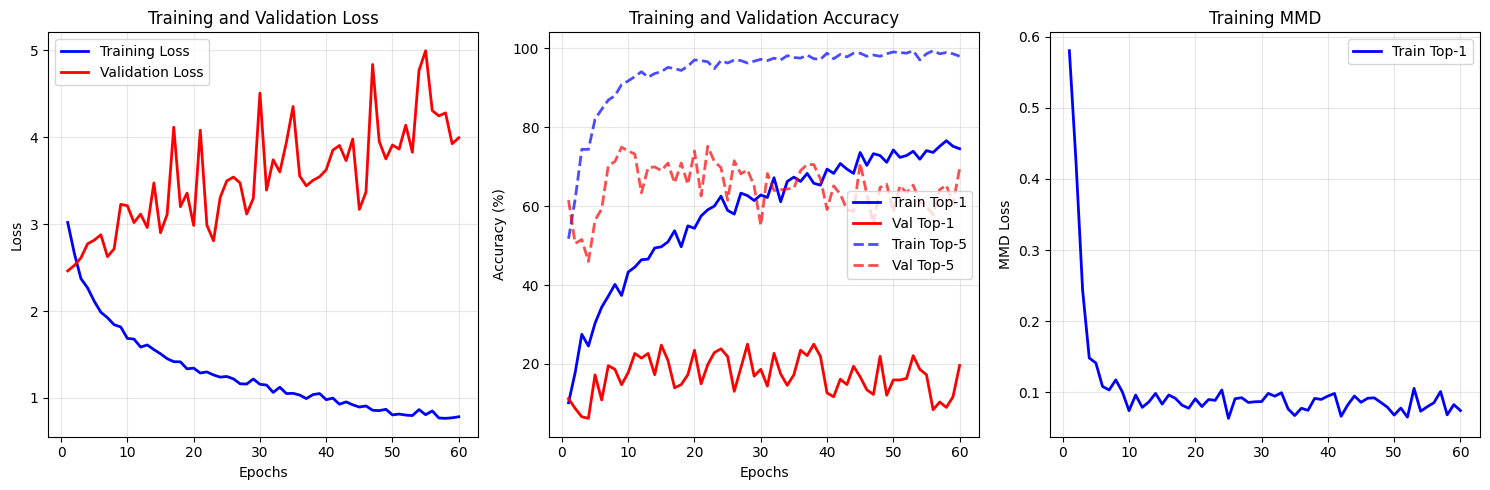

In [31]:
plot_training_metrics(metrics)